Apresentação da Base de dados:

Arquivo datatran2026.csv
Trata-se da base pública DATATRAN,  disponibilizada pelo Ministério da Infraestrutura/Polícia Rodoviária Federal, que reúne registros de acidentes de trânsito em rodovias federais brasileiras.

Colunas principais:

data_inversa: data do acidente.

horario: horário do acidente.

dia_semana: dia da semana.

uf: estado onde ocorreu.

municipio: cidade onde ocorreu.

tipo_acidente: classificação do acidente (colisão, atropelamento, saída de pista etc.).

causa_acidente: causa provável registrada.

mortos, feridos_leves, feridos_graves: consequências em termos de vítimas.

Outras colunas complementares como condições da via, tipo de veículo, etc.


Recorte temporal: O arquivo que você anexou é de 2026, ou seja, cobre todos os acidentes registrados nesse ano.


Perguntas que queremos responder antes da análise da base de dados:


Quais os horários do dia com maior número de acidentes?  
→ Identificar picos de ocorrência (manhã, tarde, noite, madrugada).

Quais dias da semana concentram mais acidentes?  
→ Comparar finais de semana com dias úteis.

Quais estados ou municípios registraram mais acidentes em 2026?  
→ Mapear regiões críticas.

Quais tipos de acidente são mais frequentes?  
→ Colisão, atropelamento, saída de pista etc.

Qual a gravidade dos acidentes (mortos, feridos graves, feridos leves) ao longo do ano?  
→ Avaliar impacto humano e possíveis sazonalidades.

Importação das bibliotecas utilizadas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importando a tabela datatran2026


Usamos o encoding latin para o utf8 e o separador ; conforme está no arquivo csv.


In [2]:
tabela = pd.read_csv('datatran2026.csv', encoding='latin1', sep=';' )
display(tabela.head())
display(tabela.tail())

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,742921,2026-01-01,quinta-feira,04:04:00,TO,153,155,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,...,0,1,3,0,5,"-7,291548","-48,286252",SPRF-TO,DEL02-TO,UOP01-DEL02-TO
1,742942,2026-01-01,quinta-feira,06:40:00,MG,262,"146,1",RIO CASCA,Condutor Dormindo,Colisão frontal,...,4,1,1,4,3,"-20,0240733","-42,7422291",SPRF-MG,DEL03-MG,UOP03-DEL03-MG
2,742943,2026-01-01,quinta-feira,06:58:00,SC,101,193,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,...,0,1,2,1,4,"-27,48935222","-48,65565777",SPRF-SC,DEL01-SC,UOP01-DEL01-SC
3,742947,2026-01-01,quinta-feira,07:05:00,DF,60,23,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,1,1,1,3,"-15,988927","-48,2263",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
4,742960,2026-01-01,quinta-feira,06:17:00,MT,163,1044,MATUPA,Transitar na contramão,Colisão frontal,...,1,1,3,1,5,"-10,14330603","-54,93075559",SPRF-MT,DEL06-MT,UOP03-DEL06-MT


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
42317,795413,2026-05-30,sábado,23:30:00,MG,365,623,UBERLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,0,1,0,0,2,"-18,90771269","-48,29991531",SPRF-MG,DEL15-MG,UOP01-DEL15-MG
42318,795594,2026-07-28,terça-feira,12:30:00,DF,60,"0,3",BRASILIA,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,2,1,0,2,2,"-15,883242","-48,063643",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
42319,795706,2026-07-09,quinta-feira,18:45:00,PA,163,312,NOVO PROGRESSO,Acessar a via sem observar a presença dos outr...,Colisão transversal,...,0,0,3,0,2,"-7,028179","-55,419506",SPRF-PA,DEL05-PA,UOP03-DEL05-PA
42320,795871,2026-07-13,segunda-feira,14:06:00,DF,70,6,BRASILIA,Acessar a via sem observar a presença dos outr...,Colisão traseira,...,0,1,0,1,2,"-15,79007522","-48,10886264",SPRF-DF,DEL03-DF,UOP02-DEL03-DF
42321,795942,2026-05-24,domingo,03:00:00,GO,153,"437,2",ANAPOLIS,Reação tardia ou ineficiente do condutor,Colisão com objeto,...,0,0,0,2,1,"-16,30447887","-48,9243713",SPRF-GO,DEL02-GO,UOP01-DEL02-GO


Abaixo as primeiras análises e conferencias na tabela


 quantas linhas e colunas tem?
 
  Quais os tipos de cada coluna?
  
   Quanta memória ocupa? 
   
   Há valores faltantes?

In [3]:
print("shape:", tabela.shape)
print()
tabela.info()
print()
print(tabela.isna().sum())

shape: (42322, 30)

<class 'pandas.DataFrame'>
RangeIndex: 42322 entries, 0 to 42321
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      42322 non-null  int64
 1   data_inversa            42322 non-null  str  
 2   dia_semana              42322 non-null  str  
 3   horario                 42322 non-null  str  
 4   uf                      42322 non-null  str  
 5   br                      42322 non-null  int64
 6   km                      42322 non-null  str  
 7   municipio               42322 non-null  str  
 8   causa_acidente          42322 non-null  str  
 9   tipo_acidente           42322 non-null  str  
 10  classificacao_acidente  42321 non-null  str  
 11  fase_dia                42322 non-null  str  
 12  sentido_via             42322 non-null  str  
 13  condicao_metereologica  42322 non-null  str  
 14  tipo_pista              42322 non-null  str  
 15  tracado_vi

In [4]:
# Convertendo  colunas para os tipos certos, data e horario
tabela['data_inversa'] = pd.to_datetime(tabela['data_inversa'])

# Removendo  aspas da coluna horario, com elas o sistema não reconhecia o formato de hora.
# detalhe importante, após a conversão da tabela horario para datetime, se executar esse comando novamente
# vai gerar erro, pois o horário não é mais str, portanto rodar esse comando apenas uma vez ou
# ou resetar o kernel para rodar tudo novamente.
tabela['horario'] = tabela['horario'].str.replace('"', '')
tabela['horario'] = pd.to_datetime(tabela['horario'], format='%H:%M:%S', errors='coerce')

In [5]:
# Criando novas colunas fazendo separação de data e horario
tabela['ano'] = tabela['data_inversa'].dt.year
tabela['mes'] = tabela['data_inversa'].dt.month
tabela['dia'] = tabela['data_inversa'].dt.day
tabela['hora'] = tabela['horario'].dt.hour
tabela['minuto'] = tabela['horario'].dt.minute
tabela['nome_mes'] = tabela['data_inversa'].dt.month_name(locale='pt_BR')
tabela['nome_dia'] = tabela['data_inversa'].dt.day_name(locale='pt_BR')

In [6]:
# Imprimindo apenas as alterações para conferir o resultado


print(tabela[['data_inversa','ano','mes','dia', 'nome_mes', 'nome_dia','horario','hora','minuto']].head())

  data_inversa   ano  mes  dia nome_mes      nome_dia             horario  \
0   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 04:04:00   
1   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:40:00   
2   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:58:00   
3   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 07:05:00   
4   2026-01-01  2026    1    1  Janeiro  Quinta-feira 1900-01-01 06:17:00   

   hora  minuto  
0     4       4  
1     6      40  
2     6      58  
3     7       5  
4     6      17  


In [7]:
#verificando se não tem nenhum campo horário preenchido com NAT
print(tabela[tabela['horario'].isna()].head())
# verificando se todas as datas foram convertidas corretamente
print(tabela[tabela['data_inversa'].isna()].head())





Empty DataFrame
Columns: [id, data_inversa, dia_semana, horario, uf, br, km, municipio, causa_acidente, tipo_acidente, classificacao_acidente, fase_dia, sentido_via, condicao_metereologica, tipo_pista, tracado_via, uso_solo, pessoas, mortos, feridos_leves, feridos_graves, ilesos, ignorados, feridos, veiculos, latitude, longitude, regional, delegacia, uop, ano, mes, dia, hora, minuto, nome_mes, nome_dia]
Index: []

[0 rows x 37 columns]
Empty DataFrame
Columns: [id, data_inversa, dia_semana, horario, uf, br, km, municipio, causa_acidente, tipo_acidente, classificacao_acidente, fase_dia, sentido_via, condicao_metereologica, tipo_pista, tracado_via, uso_solo, pessoas, mortos, feridos_leves, feridos_graves, ilesos, ignorados, feridos, veiculos, latitude, longitude, regional, delegacia, uop, ano, mes, dia, hora, minuto, nome_mes, nome_dia]
Index: []

[0 rows x 37 columns]


In [8]:
# Conferindo os dias da semana para certificar de não ter valor incorreto
print(tabela['dia_semana'].unique())


<StringArray>
[ 'quinta-feira',   'sexta-feira',        'sábado',       'domingo',
 'segunda-feira',   'terça-feira',  'quarta-feira']
Length: 7, dtype: str


In [9]:
# VErificando se há linhas duplicadas
print(tabela.duplicated().sum())


0


In [10]:
# --- Outliers com método IQR ---
# Aqui usamos o método do intervalo interquartil (IQR) para identificar valores extremos.
# Exemplo aplicado na coluna 'mortos'

Q1 = tabela['mortos'].quantile(0.25)   # primeiro quartil
Q3 = tabela['mortos'].quantile(0.75)   # terceiro quartil
IQR = Q3 - Q1                          # intervalo interquartil

# Definição de outliers: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
outliers_mortos = tabela[(tabela['mortos'] < Q1 - 1.5*IQR) | (tabela['mortos'] > Q3 + 1.5*IQR)]

print("Outliers em mortos:\n", outliers_mortos[['data_inversa','uf','municipio','tipo_acidente','mortos']])


Outliers em mortos:
       data_inversa  uf     municipio                  tipo_acidente  mortos
0       2026-01-01  TO     ARAGUAINA                     Tombamento       1
33      2026-01-02  PR      GUAIRACA            Colisão transversal       1
34      2026-01-02  RS       PELOTAS                Colisão frontal      11
45      2026-01-02  CE       ARACATI  Colisão lateral mesmo sentido       1
49      2026-01-02  RJ   BARRA MANSA      Atropelamento de Pedestre       1
...            ...  ..           ...                            ...     ...
42250   2026-05-10  SC        APIUNA                Colisão frontal       1
42287   2026-06-23  TO        PARANA               Colisão traseira       1
42300   2026-01-21  RN    PARNAMIRIM      Atropelamento de Pedestre       1
42307   2026-06-04  SE  AREIA BRANCA                Colisão frontal       4
42317   2026-05-30  MG    UBERLANDIA               Colisão traseira       2

[3012 rows x 5 columns]


VEja que o método identificou 3012 outliers em mortos, isso ocorre porque a distribuição é altamente enviesada para 0 mortos.
Os outliers relevantes são acidentes com mais de 3 ou 4 mortos, pois representam eventos de maior gravidade e menor frequencia
O acidente com 11 mortos é o principal destaque como outlier verdadeiro.

Abaixo adicionamos um boxplot para melhor visualização dos casos extremos.

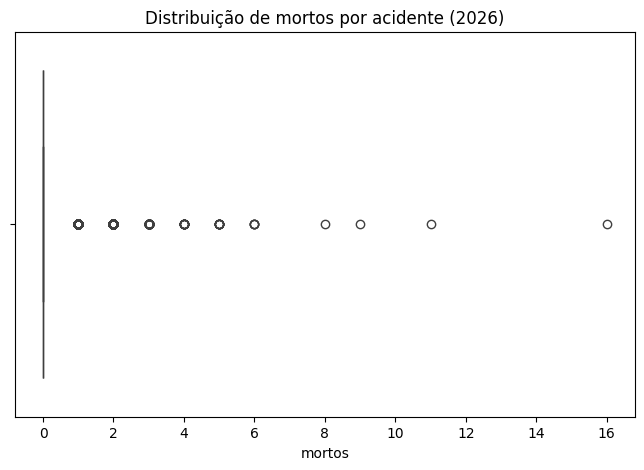

In [11]:


plt.figure(figsize=(8,5))
sns.boxplot(x=tabela['mortos'])
plt.title('Distribuição de mortos por acidente (2026)')
plt.show()


Abaixo a análise de outlier para feridos graves e leves


In [12]:
# --- Outliers em feridos graves (IQR) ---
Q1_fg = tabela['feridos_graves'].quantile(0.25)
Q3_fg = tabela['feridos_graves'].quantile(0.75)
IQR_fg = Q3_fg - Q1_fg

outliers_fg = tabela[(tabela['feridos_graves'] < Q1_fg - 1.5*IQR_fg) | (tabela['feridos_graves'] > Q3_fg + 1.5*IQR_fg)]
print("Outliers em feridos graves:\n", outliers_fg[['data_inversa','uf','municipio','tipo_acidente','feridos_graves']])


Outliers em feridos graves:
       data_inversa  uf                municipio                 tipo_acidente  \
1       2026-01-01  MG                RIO CASCA               Colisão frontal   
4       2026-01-01  MT                   MATUPA               Colisão frontal   
9       2026-01-01  ES  VENDA NOVA DO IMIGRANTE            Colisão com objeto   
14      2026-01-01  ES                 LINHARES     Atropelamento de Pedestre   
17      2026-01-01  PR    CAMPINA GRANDE DO SUL     Saída de leito carroçável   
...            ...  ..                      ...                           ...   
42290   2026-07-09  RJ           ANGRA DOS REIS  Queda de ocupante de veículo   
42303   2026-07-20  RJ                 ITABORAI              Colisão traseira   
42304   2026-07-17  SP                  UBATUBA           Colisão transversal   
42315   2026-06-23  SC                 CAMBORIU           Colisão transversal   
42318   2026-07-28  DF                 BRASILIA     Saída de leito carroçável   

In [13]:
# --- Outliers em feridos leves (IQR) ---
Q1_fl = tabela['feridos_leves'].quantile(0.25)
Q3_fl = tabela['feridos_leves'].quantile(0.75)
IQR_fl = Q3_fl - Q1_fl

outliers_fl = tabela[(tabela['feridos_leves'] < Q1_fl - 1.5*IQR_fl) | (tabela['feridos_leves'] > Q3_fl + 1.5*IQR_fl)]
print("Outliers em feridos leves:\n", outliers_fl[['data_inversa','uf','municipio','tipo_acidente','feridos_leves']])


Outliers em feridos leves:
       data_inversa  uf                  municipio  \
32      2026-01-02  MG               ANTONIO DIAS   
34      2026-01-02  RS                    PELOTAS   
36      2026-01-02  CE                       JATI   
43      2026-01-02  PR                      IRATI   
60      2026-01-03  PE               ABREU E LIMA   
...            ...  ..                        ...   
42208   2026-07-18  SC                    LONTRAS   
42213   2026-07-30  AL                      BELEM   
42245   2026-07-10  BA              SANTO ESTEVAO   
42280   2026-05-21  RS  SANTO ANTONIO DA PATRULHA   
42307   2026-06-04  SE               AREIA BRANCA   

                        tipo_acidente  feridos_leves  
32                    Colisão frontal              5  
34                    Colisão frontal              7  
36     Colisão lateral sentido oposto              3  
43     Colisão lateral sentido oposto              4  
60                   Colisão traseira              3  
...  

Feridos graves: normalmente poucos por acidente (0–2). Casos com 5, 10 ou mais feridos graves devem aparecer como outliers relevantes.

Feridos leves: há maior variação, então acidentes com dezenas de feridos leves podem ser destacados como outliers.

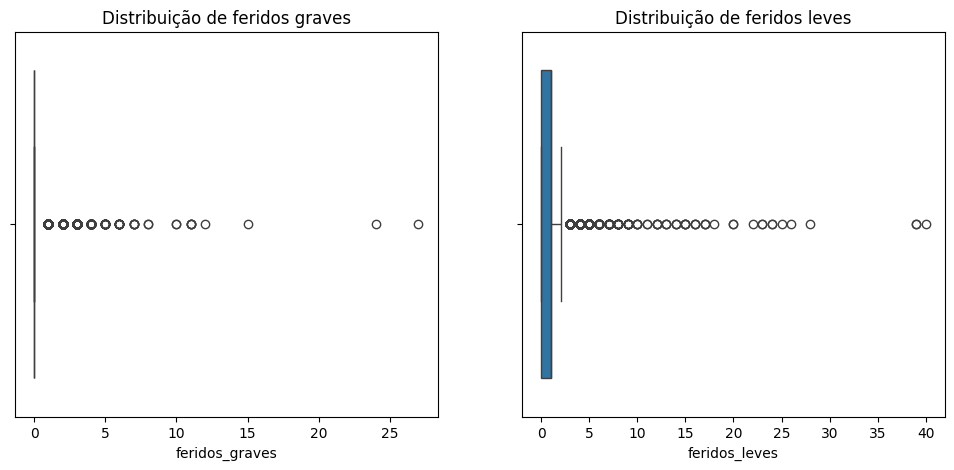

In [14]:


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=tabela['feridos_graves'])
plt.title('Distribuição de feridos graves')

plt.subplot(1,2,2)
sns.boxplot(x=tabela['feridos_leves'])
plt.title('Distribuição de feridos leves')

plt.show()


Respondendo as perguntas iniciais antes de analisar e tratar a base de dados.

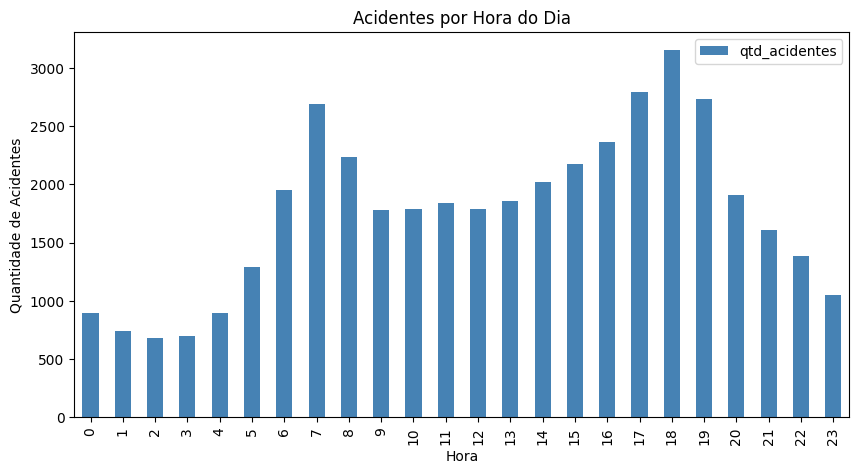

faixa_horaria
Madrugada     5193
Manhã        12282
Noite        11848
Tarde        12999
Name: id, dtype: int64


In [15]:
# Pergunta 1 – Horários com maior número de acidentes

# Agrupamento por hora
acidentes_por_hora = tabela.groupby('hora').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})
acidentes_por_hora.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title("Acidentes por Hora do Dia")
plt.xlabel("Hora")
plt.ylabel("Quantidade de Acidentes")
plt.show()

# Complemento (Merge) – adicionando faixas horárias
faixas = pd.DataFrame({
    'hora': range(0,24),
    'faixa_horaria': ['Madrugada']*6 + ['Manhã']*6 + ['Tarde']*6 + ['Noite']*6
})
tabela = tabela.merge(faixas, on='hora')

print(tabela.groupby('faixa_horaria')['id'].count())





Distribuição de acidentes por dia da semana:
               qtd_acidentes
dia_semana                  
sexta-feira             6700
domingo                 6643
sábado                  6489
quinta-feira            5905
segunda-feira           5796
quarta-feira            5469
terça-feira             5320


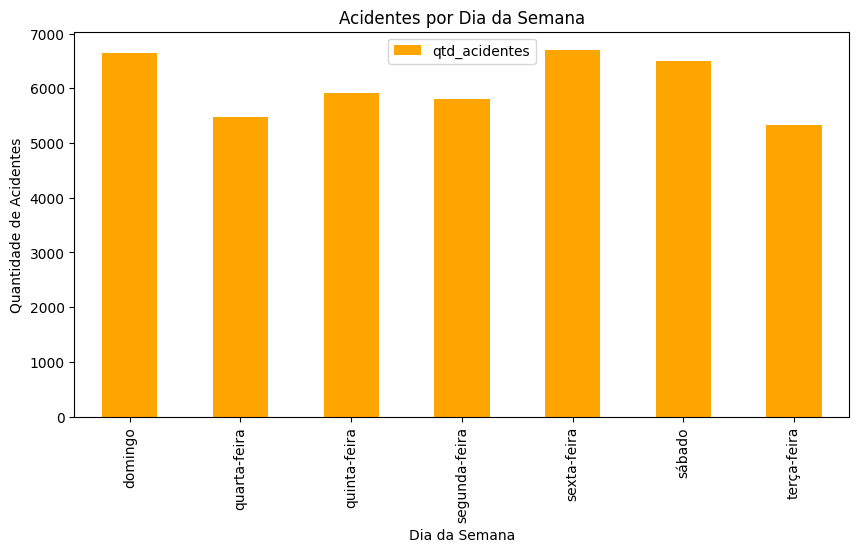

faixa_horaria  Madrugada  Manhã  Noite  Tarde
dia_semana                                   
domingo             1216   1448   2087   1892
quarta-feira         528   1719   1422   1800
quinta-feira         609   1840   1635   1821
segunda-feira        696   1980   1317   1803
sexta-feira          669   1895   2011   2125
sábado              1007   1660   1991   1831
terça-feira          468   1740   1385   1727


In [16]:
# Pergunta 2: Dias da semana com mais acidentes


# Agrupamento por dia da semana
acidentes_por_dia = tabela.groupby('dia_semana').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})

# Leitura
print("Distribuição de acidentes por dia da semana:")
print(acidentes_por_dia.sort_values('qtd_acidentes', ascending=False))


# Gráfico
acidentes_por_dia.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Acidentes por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Quantidade de Acidentes")
plt.show()


# Cruzando dia da semana com faixa horária
pivot = tabela.pivot_table(values='id', index='dia_semana', columns='faixa_horaria', aggfunc='count')
print(pivot)


Estados com mais acidentes:
    qtd_acidentes
uf               
MG           5451
SC           4902
PR           4594
RJ           3784
RS           2674

Municípios com mais acidentes:
                 qtd_acidentes
municipio                     
BRASILIA                   609
DUQUE DE CAXIAS            504
SAO JOSE                   455
BETIM                      439
RECIFE                     396


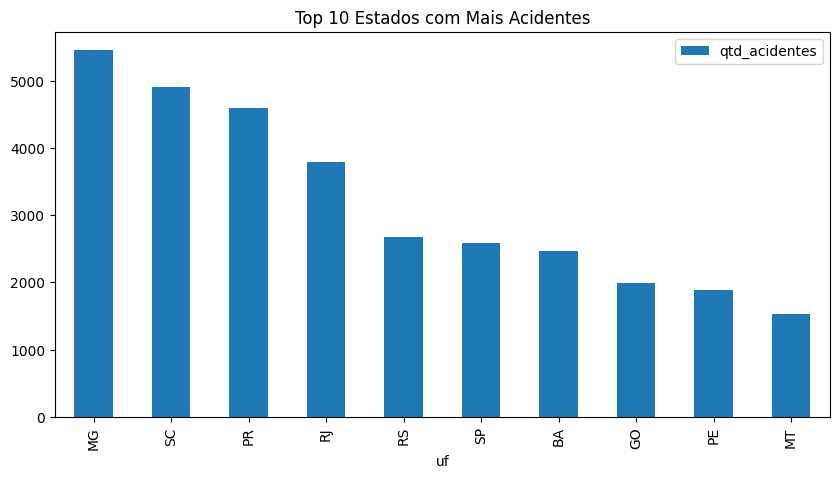

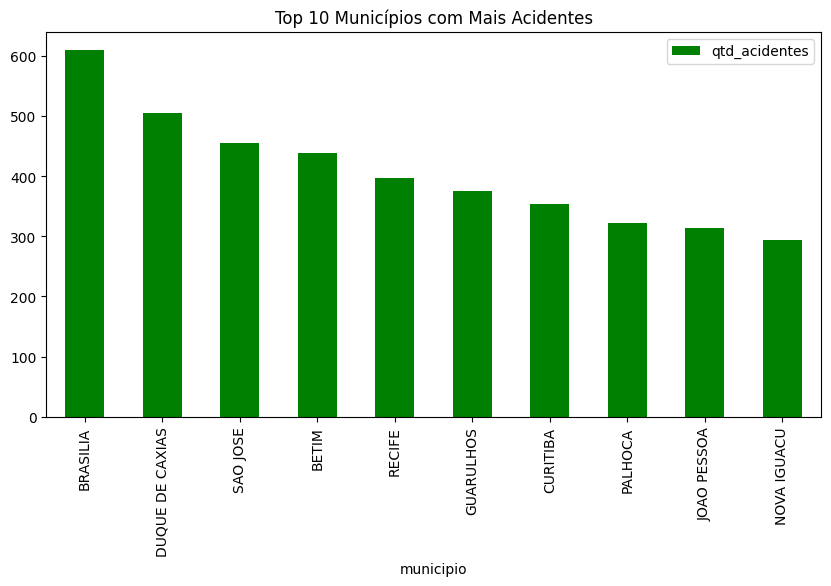

    qtd_acidentes   z_score
uf                         
MG           5451  2.573199
SC           4902  2.209434
PR           4594  2.005355
RJ           3784  1.468653
RS           2674  0.733173


In [17]:
# Pergunta 3: Estados e municípios críticos

# Estados
acidentes_por_estado = tabela.groupby('uf').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})

# Municípios
acidentes_por_municipio = tabela.groupby('municipio').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})


# Leitura
print("Estados com mais acidentes:")
print(acidentes_por_estado.sort_values('qtd_acidentes', ascending=False).head())
print("\nMunicípios com mais acidentes:")
print(acidentes_por_municipio.sort_values('qtd_acidentes', ascending=False).head())


# Gráfico estados
acidentes_por_estado.sort_values('qtd_acidentes', ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Estados com Mais Acidentes")
plt.show()

# Gráfico municípios
acidentes_por_municipio.sort_values('qtd_acidentes', ascending=False).head(10).plot(kind='bar', figsize=(10,5), color='green')
plt.title("Top 10 Municípios com Mais Acidentes")
plt.show()


# Z Score
from numpy import mean, std

valores = acidentes_por_estado['qtd_acidentes'].values
z_scores = (valores - mean(valores)) / std(valores)
acidentes_por_estado['z_score'] = z_scores

print(acidentes_por_estado.sort_values('z_score', ascending=False).head())



Tipos de acidente mais comuns:
                               qtd_acidentes
tipo_acidente                               
Colisão traseira                        8571
Saída de leito carroçável               6029
Colisão transversal                     5443
Colisão lateral mesmo sentido           4691
Tombamento                              3647


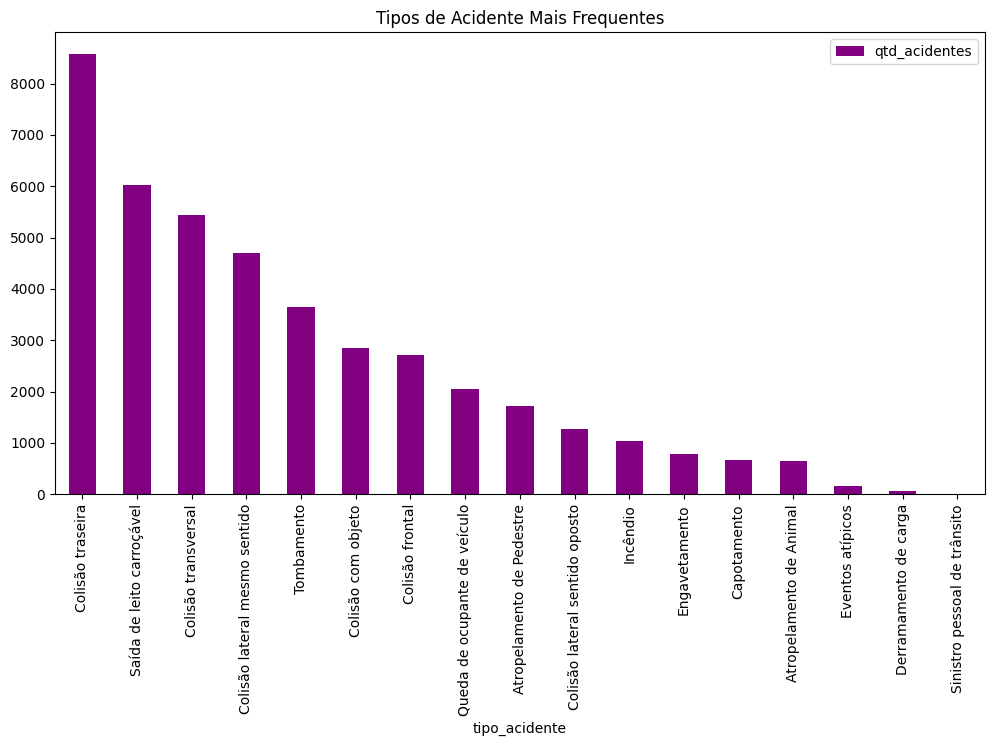

In [18]:
# Pergunta 4: Tipos de acidente mais frequentes


tipos = tabela.groupby('tipo_acidente').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})


# Leitura
print("Tipos de acidente mais comuns:")
print(tipos.sort_values('qtd_acidentes', ascending=False).head())


# Gráfico
tipos.sort_values('qtd_acidentes', ascending=False).plot(kind='bar', figsize=(12,6), color='purple')
plt.title("Tipos de Acidente Mais Frequentes")
plt.show()




Resumo da gravidade dos acidentes:
mortos             3516
feridos_graves    11489
feridos_leves     37122
dtype: int64


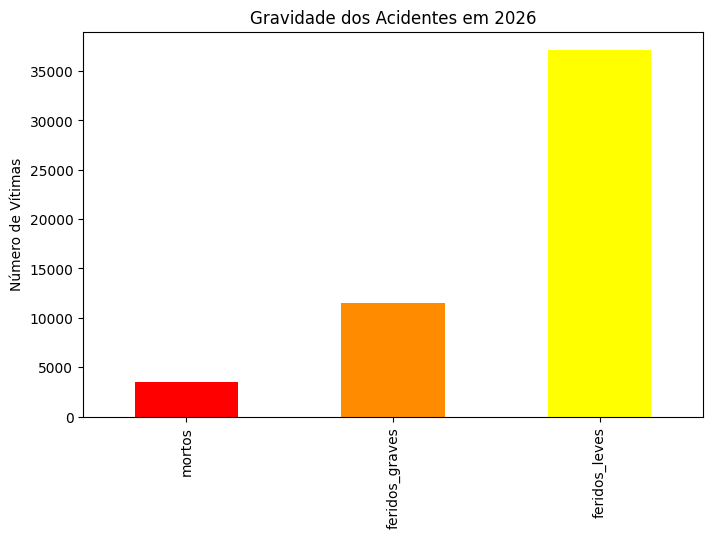

In [19]:
# Pergunta 5: Gravidade dos acidentes

gravidade = tabela[['mortos','feridos_graves','feridos_leves']].sum()


# Leitura
print("Resumo da gravidade dos acidentes:")
print(gravidade)


# Gráfico
gravidade.plot(kind='bar', figsize=(8,5), color=['red','darkorange','yellow'])
plt.title("Gravidade dos Acidentes em 2026")
plt.ylabel("Número de Vítimas")
plt.show()




Conclusões

In [20]:


# Verificar colunas categóricas
categorical_cols = tabela.select_dtypes(include="object").columns
print("Colunas categóricas:", categorical_cols)

# Frequência das categorias principais em cada coluna
for col in categorical_cols:
    print(f"\nTop categorias em {col}:")
    print(tabela[col].value_counts(normalize=True).head(5))


Colunas categóricas: Index(['dia_semana', 'uf', 'km', 'municipio', 'causa_acidente',
       'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'nome_mes',
       'nome_dia', 'faixa_horaria'],
      dtype='str')

Top categorias em dia_semana:
dia_semana
sexta-feira      0.158310
domingo          0.156963
sábado           0.153325
quinta-feira     0.139526
segunda-feira    0.136950
Name: proportion, dtype: float64

Top categorias em uf:
uf
MG    0.128798
SC    0.115826
PR    0.108549
RJ    0.089410
RS    0.063182
Name: proportion, dtype: float64

Top categorias em km:
km
0    0.004395
2    0.004182
1    0.004017
4    0.003733
3    0.003615
Name: proportion, dtype: float64

Top categorias em municipio:
municipio
BRASILIA           0.014390
DUQUE DE CAXIAS    0.011909
SAO JOSE           0.010751
BETIM              0.010373
RECIFE      

C:\Users\dougl\AppData\Local\Temp\ipykernel_23016\1886716884.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = tabela.select_dtypes(include="object").columns


In [21]:


# Verificar colunas categóricas
categorical_cols = tabela.select_dtypes(include="object").columns
print("Colunas categóricas:", categorical_cols)

# Frequência das categorias principais em cada coluna
for col in categorical_cols:
    print(f"\nTop categorias em {col}:")
    print(tabela[col].value_counts(normalize=True).head(5))


Colunas categóricas: Index(['dia_semana', 'uf', 'km', 'municipio', 'causa_acidente',
       'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'nome_mes',
       'nome_dia', 'faixa_horaria'],
      dtype='str')

Top categorias em dia_semana:
dia_semana
sexta-feira      0.158310
domingo          0.156963
sábado           0.153325
quinta-feira     0.139526
segunda-feira    0.136950
Name: proportion, dtype: float64

Top categorias em uf:
uf
MG    0.128798
SC    0.115826
PR    0.108549
RJ    0.089410
RS    0.063182
Name: proportion, dtype: float64

Top categorias em km:
km
0    0.004395
2    0.004182
1    0.004017
4    0.003733
3    0.003615
Name: proportion, dtype: float64

Top categorias em municipio:
municipio
BRASILIA           0.014390
DUQUE DE CAXIAS    0.011909
SAO JOSE           0.010751
BETIM              0.010373
RECIFE      

C:\Users\dougl\AppData\Local\Temp\ipykernel_23016\1886716884.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = tabela.select_dtypes(include="object").columns


Conclusão 1 — Perfil dos dados
Achado: Mais de 57% dos registros estão concentrados em cinco tipos principais de acidente:

Colisão traseira (20,2%)

Saída de leito carroçável (14,2%)

Colisão transversal (12,8%)

Colisão lateral mesmo sentido (11,0%)

Tombamento (8,6%)

Interpretação: A predominância desses tipos mostra que a maior parte dos acidentes está ligada a falhas de direção e dinâmica veicular, indicando pontos críticos para campanhas de prevenção e fiscalização.

Limitação: O recorte temporal/geográfico da base não garante que essa distribuição se repita em outros contextos ou regiões.

Próximo passo: Ampliar a coleta e cruzar com variáveis como horário, condição da via e clima, para verificar se esses tipos de acidente se mantêm como predominantes em diferentes cenários.

In [22]:
# Quantidade e percentual de valores faltantes por coluna
missing = tabela.isnull().sum()
missing_percent = (missing / len(tabela)) * 100
print(pd.DataFrame({"faltantes": missing, "percentual": missing_percent}))

# Duplicados
duplicados = tabela.duplicated().sum()
print(f"Registros duplicados: {duplicados} ({duplicados/len(tabela)*100:.2f}%)")


                        faltantes  percentual
id                              0    0.000000
data_inversa                    0    0.000000
dia_semana                      0    0.000000
horario                         0    0.000000
uf                              0    0.000000
br                              0    0.000000
km                              0    0.000000
municipio                       0    0.000000
causa_acidente                  0    0.000000
tipo_acidente                   0    0.000000
classificacao_acidente          1    0.002363
fase_dia                        0    0.000000
sentido_via                     0    0.000000
condicao_metereologica          0    0.000000
tipo_pista                      0    0.000000
tracado_via                     0    0.000000
uso_solo                        0    0.000000
pessoas                         0    0.000000
mortos                          0    0.000000
feridos_leves                   0    0.000000
feridos_graves                  0 

Conclusão 2 — Qualidade e confiabilidade
Achado: A base apresentou baixíssimo índice de problemas de preenchimento: apenas 34 registros com valores faltantes (0,08% do total), distribuídos em colunas como classificacao_acidente, regional, delegacia e uop. Não foram encontrados registros duplicados.

Interpretação: Isso mostra que, apesar de ser uma base “crua”, os dados têm alta integridade estrutural. O risco de enviesamento por dados ausentes ou duplicados é mínimo, o que aumenta a confiabilidade das análises.

Limitação: Mesmo com poucos faltantes, as imputações realizadas (como preenchimento por grupo ou exclusão pontual) podem introduzir pequenas incertezas. Além disso, a qualidade depende da coleta original — não temos garantia de consistência em bases futuras.

Próximo passo: Reforçar processos de coleta e padronização, garantindo que colunas críticas (como delegacia e uop) sejam sempre preenchidas corretamente, evitando a necessidade de correções manuais.

In [23]:
# Média de vítimas por tipo de acidente
tabela.groupby("tipo_acidente")[["mortos","feridos_leves","feridos_graves"]].mean().sort_values("mortos", ascending=False).head(5)

# Distribuição por fase do dia
tabela.groupby("fase_dia")[["mortos","feridos"]].sum()


,mortos,feridos
fase_dia,,
Amanhecer,281,2444
Anoitecer,189,2714
Plena Noite,1660,15906
Pleno dia,1386,27547


Conclusão 3 — Tendências e relações
Achado:

Pleno dia concentra o maior número de acidentes com vítimas: 27.547 feridos e 1.386 mortos.

Plena noite aparece como o segundo período mais crítico, com 15.906 feridos e 1.660 mortos — ou seja, maior letalidade proporcional.

Amanhecer e Anoitecer têm incidência bem menor, mas ainda relevantes (281 mortos no amanhecer e 189 no anoitecer).

Interpretação: Os dados mostram que o dia concentra mais acidentes em volume, mas a noite concentra maior gravidade, com mais mortes em relação ao número de feridos. Isso sugere que fatores como visibilidade reduzida, fadiga e menor fiscalização podem aumentar a letalidade dos acidentes noturnos.

Limitação: A base não permite afirmar causa e efeito — não podemos concluir que “dirigir à noite causa mais mortes” sem considerar variáveis externas como condição da via, clima ou perfil dos motoristas.

Próximo passo: Cruzar fase do dia com variáveis como condição meteorológica e tipo de pista para entender melhor os fatores que aumentam a gravidade dos acidentes em cada período.

## Diagnóstico complementar de qualidade

# Categorias "quase faltantes" e inconsistências de texto

In [24]:
for coluna in ['condicao_metereologica', 'sentido_via', 'tracado_via', 'uso_solo']:
    print(f"--- {coluna} ---")
    print(tabela[coluna].value_counts(dropna=False))
    print()

# município está padronizado ou em caixa alta / mista?
print("Exemplo de municipio:", tabela['municipio'].unique()[:5])

--- condicao_metereologica ---
condicao_metereologica
Céu Claro           26217
Nublado              6993
Chuva                4265
Sol                  2119
Garoa/Chuvisco       1571
Ignorado              572
Nevoeiro/Neblina      528
Vento                  55
Neve                    1
Granizo                 1
Name: count, dtype: int64

--- sentido_via ---
sentido_via
Crescente        22390
Decrescente      19843
Não Informado       89
Name: count, dtype: int64

--- tracado_via ---
tracado_via
Reta                                                       23266
Curva                                                       4734
Aclive;Reta                                                 1122
Reta;Declive                                                1084
Declive;Reta                                                1056
                                                           ...  
Viaduto;Reta;Em Obras;Retorno Regulamentado                    1
Declive;Reta;Túnel                          

#Achados - categorias inconsistentes

- condicao_metereologica: a categoria "Ignorado" aparece em 572 registros (~1,4%). Não é uma condição climática real, é um valor ausente disfarçado de categoria — precisa ser tratado como faltante na etapa de limpeza, não como um tipo de clima válido.
- sentido_via: mesma situação com "Não Informado" (89 registros, ~0,2%) — outro faltante mascarado.
- tracado_via: essa coluna tem 470 combinações diferentes, porque empacota várias características da via num único texto separado por ; (ex: "Aclive;Reta", "Reta;Declive"). Isso dificulta usar a coluna direto em groupby ou gráfico — precisaria ser dividida em colunas binárias (ex: tem_curva, tem_aclive) antes de entrar em qualquer análise.
- uso_solo: essa está limpa — só "Sim"/"Não", sem valores estranhos. Fica como exemplo de coluna categórica que não precisa de tratamento.
- municipio: os nomes estão todos em CAIXA ALTA e sem acentuação (ex: "ARAGUAINA" em vez de "Araguaína"). Não atrapalha a contagem (porque é consistente), mas prejudica a legibilidade em tabelas e gráficos finais — vale padronizar com .str.title() na limpeza.

# Inconsistência lógica entre colunas

In [25]:
soma_esperada = tabela['mortos'] + tabela['feridos'] + tabela['ilesos'] + tabela['ignorados']

inconsistentes = tabela['pessoas'] != soma_esperada

print(f"Registros onde 'pessoas' não bate com a soma: {inconsistentes.sum()} ({inconsistentes.mean()*100:.1f}%)")

tabela.loc[inconsistentes, ['id','pessoas','mortos','feridos','ilesos','ignorados']].head()

Registros onde 'pessoas' não bate com a soma: 2239 (5.3%)


,id,pessoas,mortos,feridos,ilesos,ignorados
0,742921,3,1,0,1,3
2,742943,3,0,1,1,2
4,742960,3,0,1,1,3
7,742987,3,0,0,2,3
13,743035,2,0,0,1,2


#inconsistência em pessoas vs. soma das categorias

Em 2.239 registros (5,3% da base), o total de pessoas não corresponde à soma de mortos + feridos + ilesos + ignorados — a soma das categorias é sempre maior que o total informado. 
Não é possível determinar com certeza a causa a partir dos dados disponíveis; 
duas hipóteses são possíveis: (1) o campo ignorados não é mutuamente exclusivo das demais categorias nesses casos, ou (2) houve erro na consolidação do arquivo. 
Como não sabemos qual coluna está errada, não vamos "corrigir" esses valores — vamos documentar a inconsistência como limitação da base, e evitar usar pessoas e a soma das categorias de forma intercambiável em cálculos futuros.

#Outlier com IQR, agora por grupo

In [27]:
def eh_outlier_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return (serie < limite_inferior) | (serie > limite_superior)

# outlier de 'mortos', comparando dentro de cada tipo_pista (não no dataset inteiro)
tabela['outlier_mortos_iqr'] = tabela.groupby('tipo_pista')['mortos'].transform(eh_outlier_iqr)
print(f"Outliers de 'mortos' (IQR por tipo_pista): {tabela['outlier_mortos_iqr'].sum()}")

Outliers de 'mortos' (IQR por tipo_pista): 3012


Explicamos que o método do IQR classificou 3.012 acidentes (7,1% da base) como outlier de mortos. Na prática, isso corresponde a qualquer acidente com ao menos 1 morte: como mais de 90% dos acidentes têm zero mortos (mesmo dentro de cada tipo de pista), o IQR do grupo é zero, e o limite superior colapsa para zero — então qualquer valor positivo já é sinalizado. Isso revela uma limitação do método para variáveis com essa distribuição (dominada por zeros): o IQR não diferencia "1 morte" de "16 mortes", trata os dois como igualmente extremos. Por isso, na próxima seção comparamos com o z-score, que pode capturar melhor a diferença entre um acidente fatal comum e um caso realmente extremo

#Gráfico da distribuição de mortos

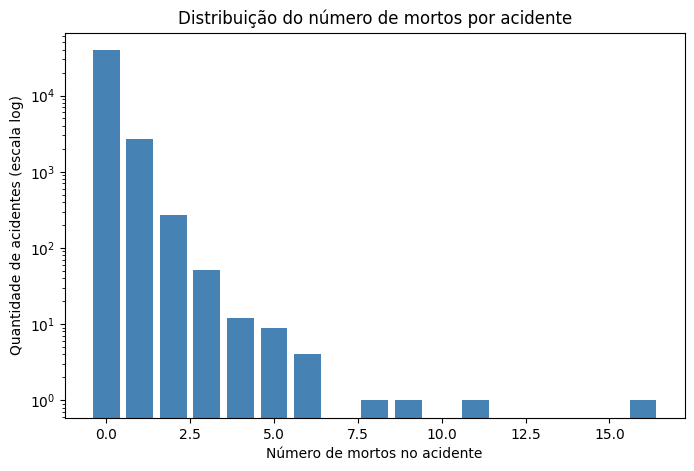

In [28]:
import matplotlib.pyplot as plt

contagem_mortos = tabela['mortos'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(contagem_mortos.index, contagem_mortos.values, color='steelblue')
plt.yscale('log')  # escala log, porque o valor 0 é muito maior que o resto
plt.xlabel('Número de mortos no acidente')
plt.ylabel('Quantidade de acidentes (escala log)')
plt.title('Distribuição do número de mortos por acidente')
plt.show()

O gráfico confirma visualmente por que o IQR classificou 7,1% dos acidentes como outlier: a barra de "0 mortos" é ordens de magnitude maior que qualquer outra (mais de 39 mil contra pouco mais de 3 mil no total de acidentes com alguma morte). Estatisticamente, qualquer valor fora do zero já rompe o padrão dominante — mesmo sendo, na prática, uma parte esperada da realidade (acidentes fatais são raros, mas ocorrem). Isso reforça a limitação do IQR pra esse tipo de variável e justifica testar o z-score como método complementar.

#Z-score no dataset inteiro (pra comparar direto com o IQR)

In [31]:
import numpy as np

def calcula_zscore(serie):
    media = np.mean(serie)
    desvio_padrao = np.std(serie)
    return (serie - media) / desvio_padrao

tabela['zscore_mortos'] = tabela.groupby('tipo_pista')['mortos'].transform(calcula_zscore)
tabela['outlier_mortos_zscore'] = tabela['zscore_mortos'].abs() > 3

print(f"IQR marcou: {tabela['outlier_mortos_iqr'].sum()} outliers")
print(f"Z-score marcou: {tabela['outlier_mortos_zscore'].sum()} outliers")

IQR marcou: 3012 outliers
Z-score marcou: 1354 outliers


#Comparando os dois métodos

In [30]:
print("IQR marcou:", tabela['outlier_mortos_iqr'].sum())
print("Z-score marcou:", tabela['outlier_mortos_zscore'].sum())
print("Os dois concordam em:", (tabela['outlier_mortos_iqr'] & tabela['outlier_mortos_zscore']).sum(), "registros")

IQR marcou: 3012
Z-score marcou: 1354
Os dois concordam em: 1354 registros


- Achado — mortes são raras, mesmo entre os acidentes

Mais de 9 em cada 10 acidentes registrados não têm nenhuma morte. Isso é uma boa notícia em termos absolutos, mas tem um efeito colateral estatístico: métodos tradicionais de detecção de outliers (como o IQR) acabam classificando qualquer acidente com ao menos 1 morte como "fora do padrão" — 3.012 casos, ou 7,1% da base — simplesmente porque o valor mais comum é zero. Isso não significa que são casos raríssimos entre si; apenas que o método não diferencia um acidente com 1 morte de um com 16.

Limitação: o IQR não é a ferramenta ideal para variáveis dominadas por um único valor (nesse caso, zero); ele identifica "teve morte ou não", não "quão grave foi, dado que houve morte".

Próximo passo: aplicar um método mais sensível à magnitude (como z-score) para diferenciar acidentes fatais comuns de casos extremos dentro do próprio grupo de acidentes com morte.

- Z-score só entre quem já teve morte

In [32]:
# aqui a pergunta muda: dado que o acidente teve morte, ele foi "comum" ou "extremo"?
acidentes_fatais = tabela[tabela['mortos'] > 0].copy()
acidentes_fatais['zscore_entre_fatais'] = acidentes_fatais.groupby('tipo_pista')['mortos'].transform(calcula_zscore)
extremos = acidentes_fatais[acidentes_fatais['zscore_entre_fatais'].abs() > 3]

print(f"Acidentes fatais extremos (dentro do próprio grupo de acidentes com morte): {len(extremos)}")
extremos[['id', 'tipo_pista', 'mortos']].sort_values('mortos', ascending=False)

Acidentes fatais extremos (dentro do próprio grupo de acidentes com morte): 44


,id,tipo_pista,mortos
7444,775455,Simples,16
34,743197,Simples,11
7053,773713,Simples,9
5357,766488,Simples,8
7881,777361,Simples,6
105,743745,Dupla,6
17645,752679,Simples,6
8025,777929,Simples,6
2078,752845,Dupla,5
1982,752227,Simples,5


Interpretação — comparação de métodos de outlier

Os três números contam uma progressão de precisão:

IQR (3.012 casos, 7,1%): marca qualquer acidente com ao menos 1 morte como outlier — método pouco discriminante aqui, porque o valor "0" domina tanto a base que qualquer desvio já rompe o limite.
Z-score no dataset inteiro (1.354 casos, 3,2%): mais rigoroso que o IQR, mas ainda mistura acidentes com 1 morte com acidentes de 5, 10, 16 mortes — todos entram no mesmo grupo de "outlier".
Z-score só entre os acidentes fatais (44 casos): essa é a pergunta certa — dado que houve morte, esse caso foi anormal até pros padrões de um acidente fatal? Isolando o problema dessa forma, sobra um grupo pequeno e genuinamente extremo (casos como o acidente com 16 mortes, bem acima da própria média de acidentes fatais do seu tipo de pista).

Conclusão prática: o método de detecção de outlier importa tanto quanto o resultado em si. Recomendamos usar a terceira abordagem (z-score condicionado aos acidentes fatais) para qualquer análise futura que precise identificar ocorrências extremas de verdade — as outras duas superestimam o problema ao tratar "ter morte" como sinônimo de "ser extremo".

Conclusão 4 

##O que os números mostram:
acidentes com morte são raros — menos de 1 em cada 10. Por isso, tentamos identificar quais desses acidentes fatais fogem do padrão, ou seja, foram casos excepcionalmente graves, e não só "mais um acidente com vítima fatal".

Na primeira tentativa, o critério usado marcou praticamente todo acidente com morte como "fora do padrão" — o que não ajuda muito, porque não distingue um caso comum de um caso realmente grave. Refinando o critério para comparar só entre os acidentes que já tiveram morte, chegamos a um grupo bem menor e mais preciso: 44 ocorrências que se destacam mesmo dentro desse grupo — incluindo um acidente com 16 mortes, muito acima do que costuma acontecer.

##Por que isso importa pra gestão: 
esses 44 casos são candidatos naturais a uma investigação mais aprofundada (causa, local, condições da via) — são os acidentes que mais fogem do esperado e que, por isso, têm mais chance de revelar um problema pontual (um trecho perigoso, uma falha recorrente) que vale a pena resolver primeiro.

In [24]:
# preenchendo nulos das colunas
tabela['regional'] = tabela['regional'].fillna('Nao Informado')
tabela['delegacia'] = tabela['delegacia'].fillna('Nao Informado')
tabela['uop'] = tabela['uop'].fillna('Nao Informado')
tabela['classificacao_acidente'] = tabela['classificacao_acidente'].fillna('Sem Vitimas')

# faixas de gravidade
tabela['total_vitimas'] = tabela['mortos'] + tabela['feridos']
tabela['faixa_gravidade'] = pd.cut(
    tabela['total_vitimas'],
    bins=[-1, 0, 2, 5, 100],
    labels=['sem vitimas', 'baixa', 'media', 'alta']
)

# taxa de letalidade
tabela['letalidade'] = np.where(tabela['pessoas'] > 0, (tabela['mortos'] / tabela['pessoas']) * 100, 0)

print("Nulos restantes:", tabela.isna().sum().sum())
print(tabela['faixa_gravidade'].value_counts())
display(tabela[['tipo_acidente', 'total_vitimas', 'faixa_gravidade', 'letalidade']].head(10))

Nulos restantes: 0
faixa_gravidade
baixa          32840
sem vitimas     6584
media           2602
alta             296
Name: count, dtype: int64


,tipo_acidente,total_vitimas,faixa_gravidade,letalidade
0,Tombamento,1,baixa,33.333333
1,Colisão frontal,4,media,0.000000
2,Colisão lateral mesmo sentido,1,baixa,0.000000
3,Colisão traseira,1,baixa,0.000000
4,Colisão frontal,1,baixa,0.000000
5,Colisão com objeto,1,baixa,0.000000
6,Colisão frontal,2,baixa,0.000000
7,Colisão traseira,0,sem vitimas,0.000000
8,Incêndio,0,sem vitimas,0.000000
9,Colisão com objeto,1,baixa,0.000000


In [ ]:
# Gráfico de barras da faixa de gravidade (reaproveitando a coluna já criada acima)
contagem_gravidade = tabela['faixa_gravidade'].value_counts()

plt.figure(figsize=(8, 4))
contagem_gravidade.plot(kind='bar', color=['#2b5c8f', '#d95f02', '#e7298a', '#66a61e'])
plt.title('Distribuição de Acidentes por Faixa de Gravidade')
plt.xlabel('Faixa de Gravidade')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
